# Run this to enable loading from relative paths

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 1
    import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


# Force matplotlib inlining 

In [2]:
%matplotlib inline

# Save plots with no embeded fonts

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']


# Figures Save Path

In [4]:
# save_prefix = r"../results/opto/"
import os
save_prefix = os.environ["OnedriveCommercial"] + r"/analysis/ver2/opto_new/"
import pathlib
try:
    pathlib.Path(save_prefix).mkdir(exist_ok=True)
    pathlib.Path(f"{save_prefix}/Performance").mkdir(exist_ok=True)
    pathlib.Path(f"{save_prefix}/RT").mkdir(exist_ok=True)
    pathlib.Path(f"{save_prefix}/Psychometric").mkdir(exist_ok=True)
except:
    print("Failed to create save dir...")

# Load Data

In [13]:
import pandas as pd
df_opto = pd.read_pickle(r"../data/opto/df_opto_all.pkl")

In [ ]:
from .common.definitions import MatrixState
df_opto_sampling = df_opto.query(f"GUI_OptoStartState1 == {int(MatrixState.stimulus_delivery)}")
df_opto_feedback = df_opto.query(f"GUI_OptoStartState1 == {int(MatrixState.WaitForReward)} and "
                                 f"GUI_OptoStartState2 == {int(MatrixState.WaitForPunish)}")
# Fixed-Time Opto
full_ft_df = df_opto_sampling.query("GUI_OptoStartDelay == 0 and GUI_OptoMaxTime == 1")
control_ft_df = df_opto_sampling.query("GUI_OptoStartDelay == 0 and abs(GUI_OptoMaxTime - 1.5) < 0.001 and "
                                       "abs(GUI_StimulusTime - 1.5) < 0.001")
early_late_ft_df = df_opto_sampling.query("(GUI_OptoStartDelay == 0 and GUI_OptoMaxTime == 0.35) or "
                                          "(GUI_OptoStartDelay == .65 and GUI_OptoMaxTime == 0.35)")
# Reaction-Time Opto
df_opto_rt = df_opto_sampling.query("abs(GUI_OptoStartDelay - 0.3) < 0.001 and "
                                    "abs(GUI_OptoMaxTime - 0.6) < 0.001")

# Helping function

In [15]:
from .opto.optoprocessor import loopConfig
from typing import Literal


def loopPlotOptoEffect(df, applyFn, single_subjects,
                       min_choice_trials,
                       which : Literal["partial", "full", "all", "feedback"] = "all",
                       stim_type : Literal["FT", "RT", "all"] = "all",
                       process_groups_together=False,
                       only_control_animals=False,
                       save_prefix="", save_figs=False):
    df = df.copy()
    control_animals = df.Name.str.startswith("WF")
    if only_control_animals:
        df = df[control_animals]
        display(df.Name.unique())
    else:
        df = df[~control_animals]
    # Filter out sessions with very few opto trials
    df = df.groupby(["Name", "Date", "SessionNum"]).filter(
                                 lambda sess_df:sess_df.OptoEnabled.sum() > 10)
    # Run the actual analysis
    return loopConfig(df, applyFn,
                      #which="full",
                      #which="partial",
                      #stim_type="FT",
                      min_choice_trials=min_choice_trials,
                      stim_type=stim_type, which=which,
                      process_groups_together=process_groups_together,
                      single_subjects=single_subjects,
                      save_prefix=save_prefix, save_figs=save_figs)



# Bars

In [16]:
from .opto.optoprocessor import EffectSizeMetric, plotOptoEffect
from .opto.optoprocessor import SplitLevelBy
from .common.definitions import BrainRegion
from functools import partial


_split_level = SplitLevelBy.Animal
applyFnAll = partial(plotOptoEffect, df_col_name="ChoiceCorrect",
                     split_level=_split_level,
                     mean_or_median="mean",
                     only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi, BrainRegion.PPC_Bi, BrainRegion.V1_Bi],
                     effect_size_metric=EffectSizeMetric.Gain,
                     num_iterations=10_000,
                )

df_full_sampling: 22718
df feedback: 0
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.0              11.0               1.0               14.0                 22718
dtype: int64

,GUI_StimulusTime,calcStimulusTime,Date
count,22718.0,NaN,NaN
min,1.0,0.000100,2020-10-02
max,1.0,1.035200,2022-01-04
mean,1.0,0.966593,NaN


Order: [<BrainRegion.V1_Bi: 3>, <BrainRegion.RSP_Bi: 18>, <BrainRegion.PPC_Bi: 9>, <BrainRegion.M2_Bi: 15>, <BrainRegion.ALM_Bi: 6>, <BrainRegion.S1_Bi: 21>, <BrainRegion.POR_Bi: 12>]
Brain Regions: [<BrainRegion.V1_Bi: 3>, <BrainRegion.PPC_Bi: 9>, <BrainRegion.M2_Bi: 15>, <BrainRegion.ALM_Bi: 6>]


Name     GUI_OptoBrainRegion  OptoCount  ControlCount  OptoAccept  ControlAccept
BVAGT4   6.0                  199        1179          True        True             1378
         9.0                  52         280           True        True              332
         15.0                 252        1368          True        True             1620
BVGAT1   3.0                  65         441           True        True              506
BVGAT2   3.0                  108        496           True        True              604
         6.0                  100        520           True        True              620
         15.0                 51         306           True        True              357
BVGAT3   3.0                  118        482           True        True              600
         6.0                  345        448           True        True              793
         9.0                  166        770           True        True              936
         15.0                

Num of Brain Regions: 4
Grp Key: BVGAT1 - len: 506  - Opto count: 65
Grp Key: BVGAT2 - len: 604  - Opto count: 108
Grp Key: BVGAT3 - len: 600  - Opto count: 118
Grp Key: vgat2.1 - len: 617  - Opto count: 164
Grp Key: vgat2.4 - len: 672  - Opto count: 263
Grp Key: vgat2.5 - len: 947  - Opto count: 304
Grp Key: vgat2.6 - len: 268  - Opto count: 104
P-value: 0.115
Grp Key: BVAGT4 - len: 332  - Opto count: 52
Grp Key: BVGAT3 - len: 936  - Opto count: 166
Grp Key: vgat2.1 - len: 333  - Opto count: 127
Grp Key: vgat2.4 - len: 654  - Opto count: 193
Grp Key: vgat2.5 - len: 214  - Opto count: 62
Grp Key: vgat2.6 - len: 381  - Opto count: 119
P-value: 0.010
Grp Key: BVAGT4 - len: 1620  - Opto count: 252
Grp Key: BVGAT2 - len: 357  - Opto count: 51
Grp Key: BVGAT3 - len: 254  - Opto count: 35
Grp Key: vgat2.1 - len: 416  - Opto count: 123
Grp Key: vgat2.4 - len: 334  - Opto count: 97
Grp Key: vgat2.5 - len: 536  - Opto count: 162
Grp Key: vgat2.6 - len: 1205  - Opto count: 298
P-value: 0.000
Grp

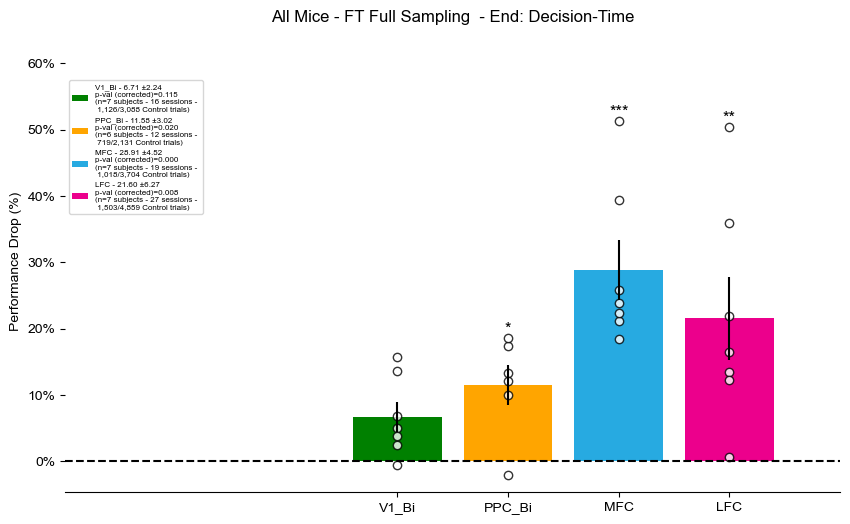

df_full_sampling: 0
df feedback: 0


In [18]:


used_full_ft_df = loopPlotOptoEffect(full_ft_df, applyFn=applyFnAll, single_subjects=False,
                                     save_prefix=save_prefix + "Performance_bar/", save_figs=False,
                                     min_choice_trials=30,
                                    )
used_full_ft_df = used_full_ft_df[0]

## Only control

array(['WF10', 'WF13', 'WF14'], dtype=object)

df_full_sampling: 1256
df feedback: 0
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.5              11.0               1.5               14.0                 1256
dtype: int64

,GUI_StimulusTime,calcStimulusTime,Date
count,1256.0,NaN,NaN
min,1.5,0.000900,2022-10-02
max,1.5,1.971200,2022-10-16
mean,1.5,1.393995,NaN


Order: [<BrainRegion.M2_Bi: 15>, <BrainRegion.V1_L: 1>]
Brain Regions: [<BrainRegion.M2_Bi: 15>]


Name  GUI_OptoBrainRegion  OptoCount  ControlCount  OptoAccept  ControlAccept
WF10  15.0                 126        534           True        True             660
WF13  15.0                 79         370           True        True             449
WF14  15.0                 25         120           True        True             145
dtype: int64

Num of Brain Regions: 1
Grp Key: WF10 - len: 660  - Opto count: 126
Grp Key: WF13 - len: 449  - Opto count: 79
Grp Key: WF14 - len: 145  - Opto count: 25
P-value: 0.779
Start state: Sampling (1.5s)


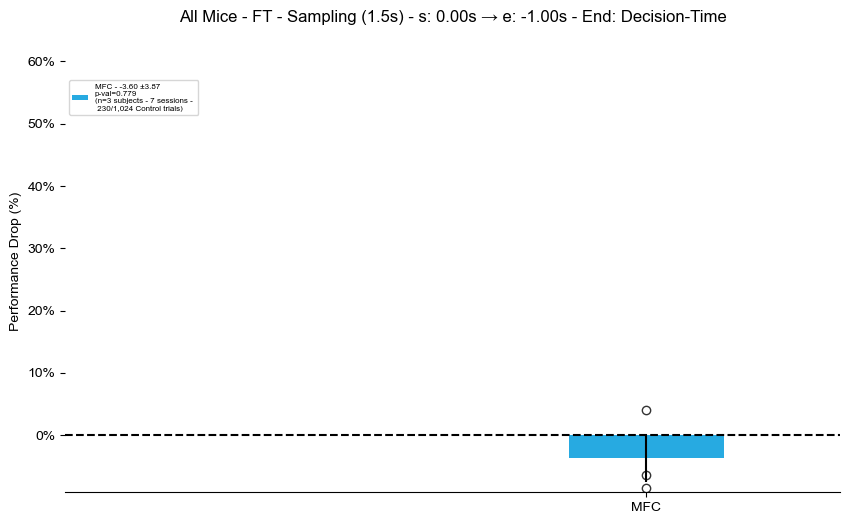

df_full_sampling: 0
df feedback: 0


In [17]:
used_control_df = loopPlotOptoEffect(control_ft_df, applyFn=applyFnAll, single_subjects=False,
                                     save_prefix=save_prefix + "Performance_Control/", save_figs=False,
                                     only_control_animals=True,
                                     min_choice_trials=0,
                                )
used_control_df = used_control_df[0]

## Only two areas

In [ ]:
from .opto.optoprocessor import EffectSizeMetric, plotOptoEffect
from .opto.optoprocessor import SplitLevelBy
from .common.definitions import BrainRegion
from functools import partial


_split_level = SplitLevelBy.Animal
applyFn2Area = partial(plotOptoEffect, df_col_name="ChoiceCorrect",
                       split_level=_split_level,
                       mean_or_median="mean",
                       only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi],
                       effect_size_metric=EffectSizeMetric.Gain,
                       num_iterations=10_000,
                )

used_early_late_ft_df = loopPlotOptoEffect(early_late_ft_df,
                                           applyFn=applyFn2Area, single_subjects=False,
                                           stim_type="FT",
                                           save_prefix=save_prefix + "Performance_bar/", save_figs=False,
                                           process_groups_together=True,
                                           min_choice_trials=30,
                                           )
used_early_late_ft_df = used_early_late_ft_df[0]

df_full_sampling: 0
df feedback: 0
Order: [<BrainRegion.V1_Bi: 3>, <BrainRegion.PPC_Bi: 9>, <BrainRegion.M2_Bi: 15>, <BrainRegion.ALM_Bi: 6>, <BrainRegion.M2_R: 14>]
Brain Regions: [<BrainRegion.M2_Bi: 15>, <BrainRegion.ALM_Bi: 6>]


Name     GUI_OptoBrainRegion  OptoCount  ControlCount  OptoAccept  ControlAccept
Avgat1   6.0                  38         157           True        True              195
                              59         262           True        True              321
         15.0                 90         298           True        True              388
Avgat2   6.0                  57         235           True        True              292
         15.0                 0          25            False       False              25
Avgat4   6.0                  42         194           True        True              236
BVAGT4   6.0                  51         349           True        True              400
                              67         230           True        True              297
         15.0                 42         216           True        True              258
                              106        481           True        True              587
BVGAT1   6.0                 

Num of Brain Regions: 2
********************* Check the next part carefully *********************


Name     OptoBrainRegion  Phase  OptoCount  ControlCount  ControlPerf  OptoPerf  OptoEffect
Avgat1   ALM              Early  38         157           0.758065     0.781250  -3.058511      195
                          Late   59         262           0.678295     0.711864  -4.949153      321
         M2               Early  90         298           0.771127     0.650602   15.629642     388
Avgat2   ALM              Early  57         235           0.732673     0.792453  -8.159102      292
Avgat4   ALM              Early  42         194           0.838150     0.815789   2.667877      236
BVAGT4   ALM              Early  67         230           0.804651     0.473684   41.131731     297
                          Late   51         349           0.758721     0.627451   17.301480     400
         M2               Early  106        481           0.807018     0.696970   13.636364     587
                          Late   42         216           0.823864     0.476190   42.200328     258
BVGAT1  

Bootstrap iterations:   0%|          | 0/10000 [00:00<?, ?it/s]

# Reaction Time Distribution

df_full_sampling: 0
df feedback: 0
Df len: 49034
Repeated Measures ANOVA Reaction-Time Results:
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Condition 14.1875 2.0000 12.0000 0.0007


Main effect of Condition: p = 0.0006893

Post-hoc pairwise comparisons (paired t-tests, Holm-corrected):
Control vs MFC: t=4.331, p_raw=0.004925, p_corr=0.01478, significant=True
Control vs LFC: t=3.557, p_raw=0.01197, p_corr=0.02394, significant=True
MFC vs LFC: t=-2.543, p_raw=0.04389, p_corr=0.04389, significant=True


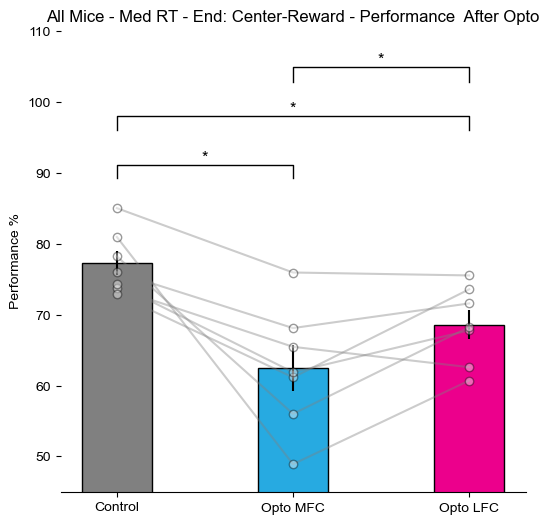

Repeated Measures ANOVA Reaction-Time Results:
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Condition  8.3667 2.0000 12.0000 0.0053


Main effect of Condition: p = 0.005306

Post-hoc pairwise comparisons (paired t-tests, Holm-corrected):
Control vs MFC: t=-3.774, p_raw=0.00925, p_corr=0.02775, significant=True
Control vs LFC: t=-1.331, p_raw=0.2314, p_corr=0.2314, significant=False
MFC vs LFC: t=3.162, p_raw=0.01953, p_corr=0.03905, significant=True


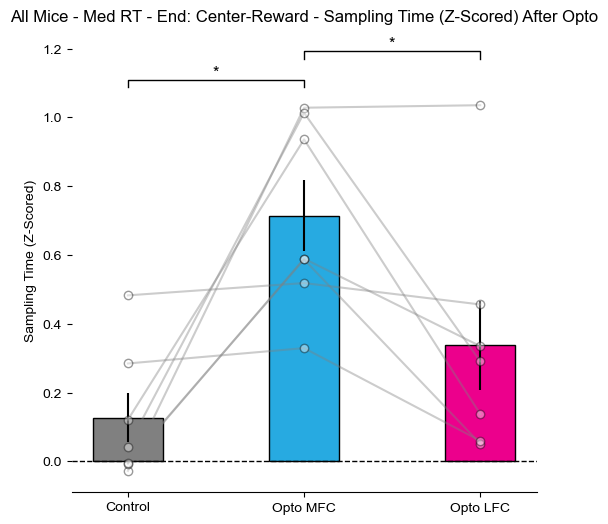

Repeated Measures ANOVA Reaction-Time Results:
                 Anova
          F Value Num DF  Den DF Pr > F
---------------------------------------
Condition 17.8097 2.0000 12.0000 0.0003


Main effect of Condition: p = 0.0002561

Post-hoc pairwise comparisons (paired t-tests, Holm-corrected):
Control vs MFC: t=-8.669, p_raw=0.0001299, p_corr=0.0003898, significant=True
Control vs LFC: t=-1.117, p_raw=0.3067, p_corr=0.3067, significant=False
MFC vs LFC: t=3.563, p_raw=0.01188, p_corr=0.02377, significant=True


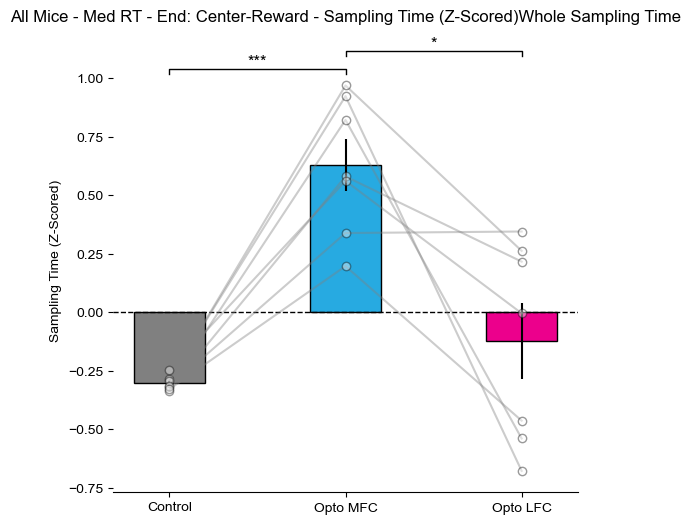

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\opto\optoreactiontime.py:712: RuntimeWarning: Mean of empty slice.
  arr_mean = arr.mean()
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


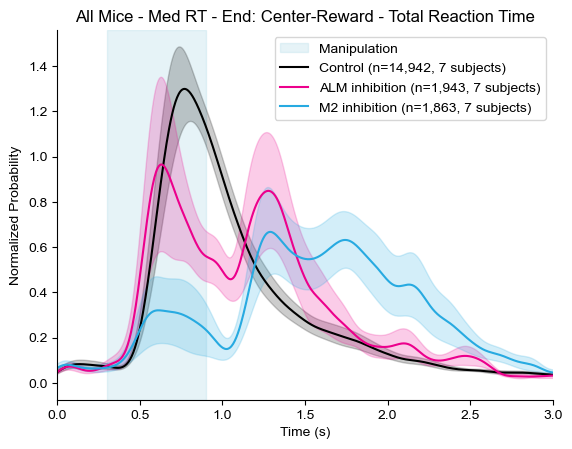

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\opto\optoreactiontime.py:712: RuntimeWarning: Mean of empty slice.
  arr_mean = arr.mean()
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


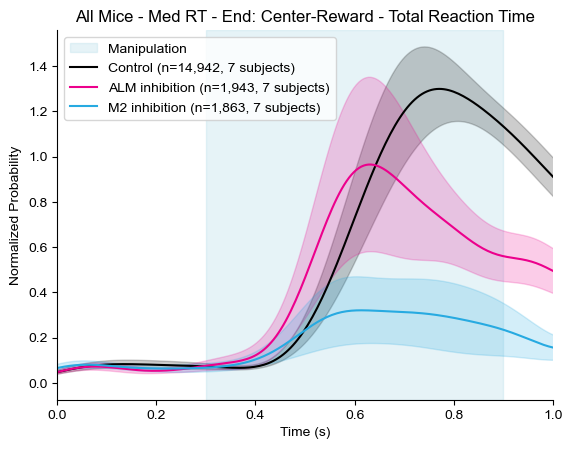

c:\Users\float\OneDrive - Floating Reality\Documents\Hatem\paper_fast_slow\code\opto\optoreactiontime.py:712: RuntimeWarning: Mean of empty slice.
  arr_mean = arr.mean()
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


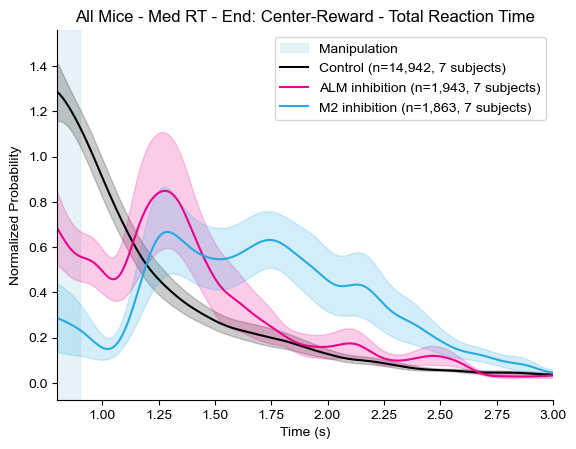

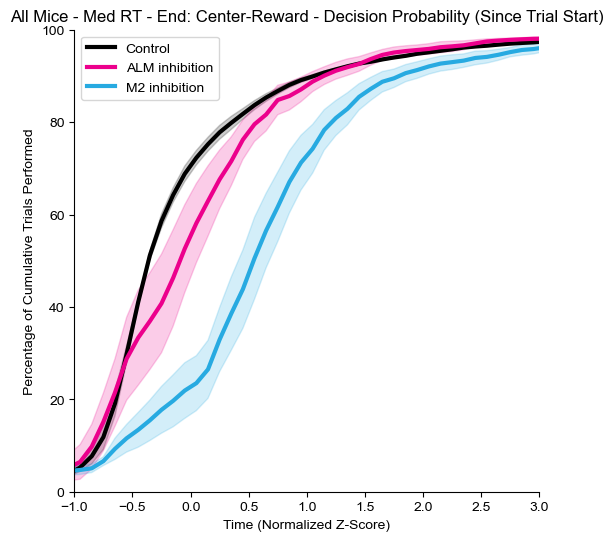

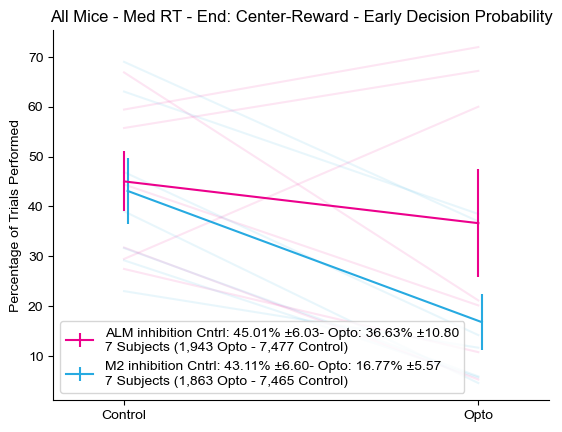

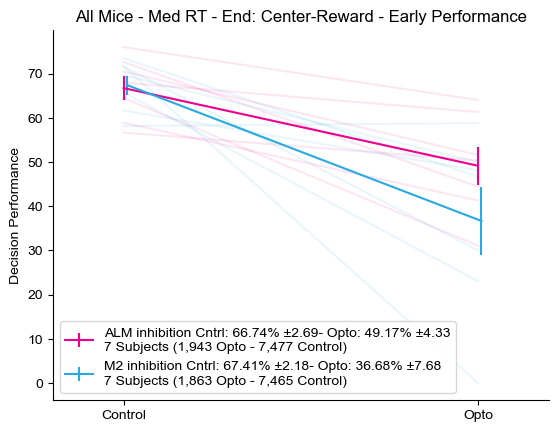

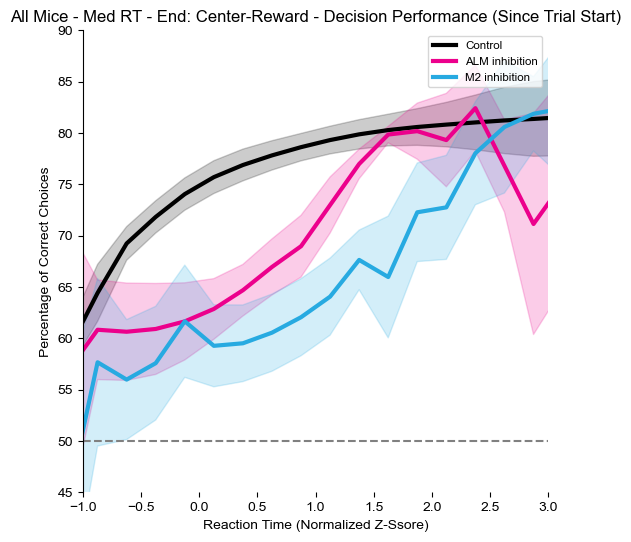

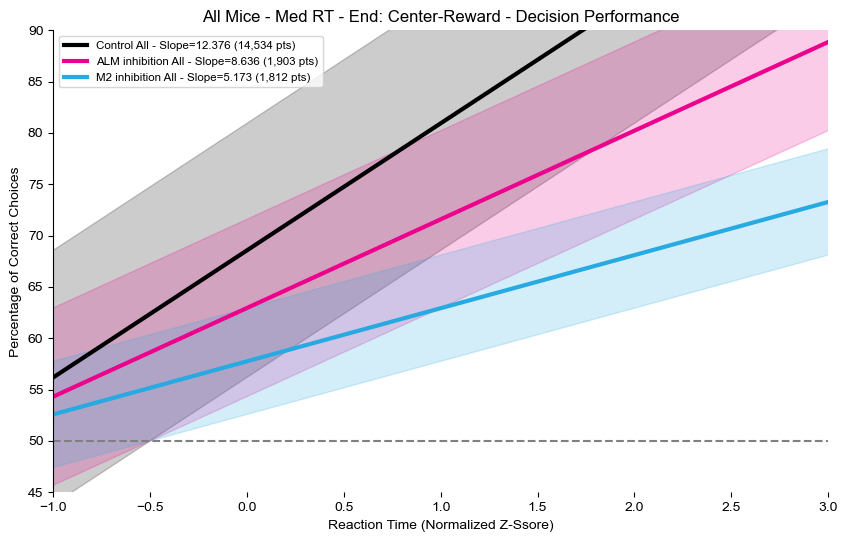

In [ ]:
from .opto.optoreactiontime import optoReactionTime
from .common.definitions import BrainRegion, MatrixState
from .opto.optoprocessor import SplitLevelBy
from functools import partial

applyFn = partial(optoReactionTime, z_score=True, plot_sem=True,
                  only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi], )

used_rt_df = loopPlotOptoEffect(df_opto_rt,
                                applyFn=applyFn, single_subjects=False,
                                save_prefix=save_prefix + "/RT/", save_figs=False,
                                stim_type="RT",
                                min_choice_trials=30,
                                )
used_rt_df = used_rt_df[0]

# Opto Feedback

df_full_sampling: 0
df feedback: 15757
Df len: 15757
Start state: WaitForReward
TODO: **********TODO: Use min_choice_trials

--- Within-Condition (Correct vs Incorrect) ---
Cntrl: t=-2.08, p_raw=0.1296, p_holm=0.2591
Opto_MFC: t=-0.67, p_raw=0.5534, p_holm=0.5534
Opto_LFC: t=-3.08, p_raw=0.0542, p_holm=0.1627

--- Cross-Region Correct (RM ANOVA) ---
               Anova
       F Value Num DF Den DF Pr > F
-----------------------------------
Region 29.1506 2.0000 6.0000 0.0008

--- Pairwise Correct (Holm) ---
Cntrl vs Opto_MFC: t=-6.54, p_holm=0.0218
Cntrl vs Opto_LFC: t=0.87, p_holm=0.4495
Opto_MFC vs Opto_LFC: t=6.07, p_holm=0.0218

--- Cross-Region Incorrect (RM ANOVA) ---
               Anova
       F Value Num DF Den DF Pr > F
-----------------------------------
Region  5.9792 2.0000 6.0000 0.0373

--- Pairwise Incorrect (Holm) ---
Cntrl vs Opto_MFC: t=-2.72, p_holm=0.2176
Cntrl vs Opto_LFC: t=0.18, p_holm=0.8701
Opto_MFC vs Opto_LFC: t=2.41, p_holm=0.2176


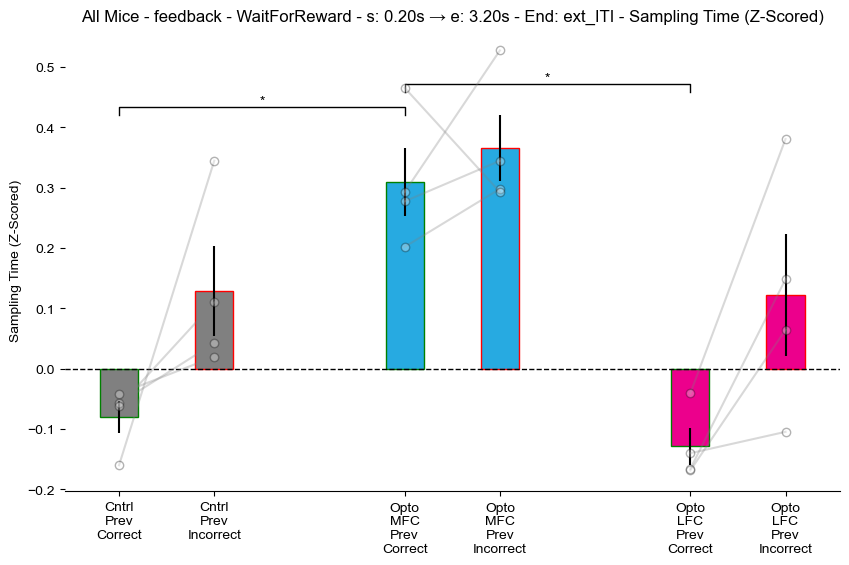

In [20]:
from .opto.optofeedback import optoFeedback
from .common.definitions import BrainRegion, MatrixState
from .opto.optoprocessor import SplitLevelBy
from functools import partial


def runFeedbackOptoAnalysis(df_opto_feedback, combine_control, z_score,
                            z_score_how : Literal["Subject", "Session"],
                            plot_as_difference : bool):
    applyFn = partial(optoFeedback, z_score=z_score, z_score_how=z_score_how,
                      combine_control=combine_control, plot_sem=False,
                      only_brain_regions=[BrainRegion.ALM_Bi, BrainRegion.M2_Bi],
                      plot_as_difference=plot_as_difference,
                      num_iterations=10_000,
                      )

    used_rt_df = loopPlotOptoEffect(df_opto_feedback,
                                    applyFn=applyFn, single_subjects=False,
                                    stim_type="feedback",
                                    min_choice_trials=30,
                                    save_prefix=save_prefix + "/feedback/",
                                    save_figs=False,
                                    )
    used_rt_df = used_rt_df[0]
    return used_rt_df

z_score_how="Subject"
runFeedbackOptoAnalysis(df_opto_feedback, combine_control=True, z_score=True,
                        z_score_how=z_score_how, plot_as_difference=False)
None

# Psychometric

In [ ]:
from .opto.optoprocessor import plotOptoPsych, SplitLevelBy
from functools import partial

applyFn = partial(plotOptoPsych,  split_level=SplitLevelBy.AllAnimals)
common_kwargs = dict(applyFn=applyFn, single_subjects=False,
                     save_figs=True,
                    )

df_full_sampling: 20602
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.0              11.0               1.0               14.0                 20602
dtype: int64

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,20602.0,NaN,NaN,NaN,NaN
min,1.0,0.800000,0.000100,0.000100,2020-10-02
max,1.0,1.000000,1.035200,1.000200,2021-12-26
mean,1.0,0.995538,0.964706,0.966139,NaN


Start state: Sampling
Control Trials: 3088
Opto Trials: 1126
Plotting overall psychometric
Mean: 57.77777777777777 - SEM: nan - len(perf_col): 1
Mean: 53.333333333333336 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 64.28571428571429 - SEM: nan - len(perf_col): 1
Mean: 73.33333333333333 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


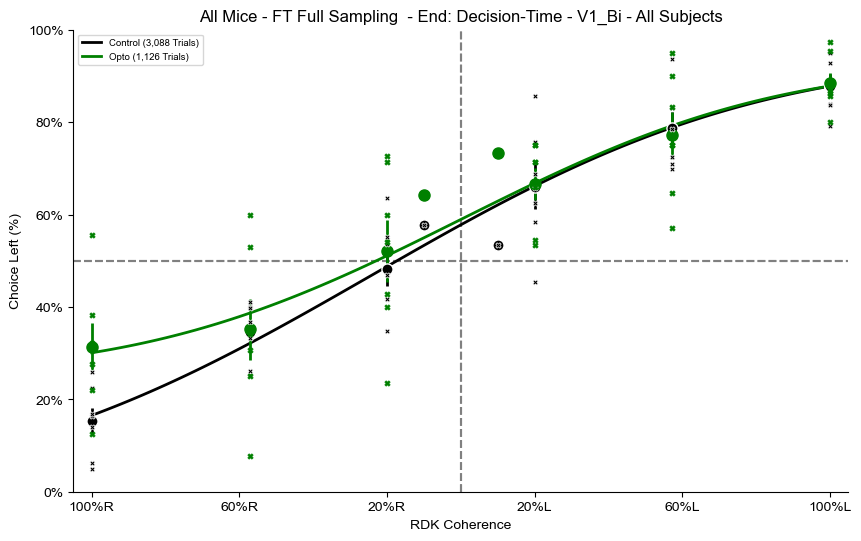

Control Trials: 4859
Opto Trials: 1503
Plotting overall psychometric
Plotting overall psychometric


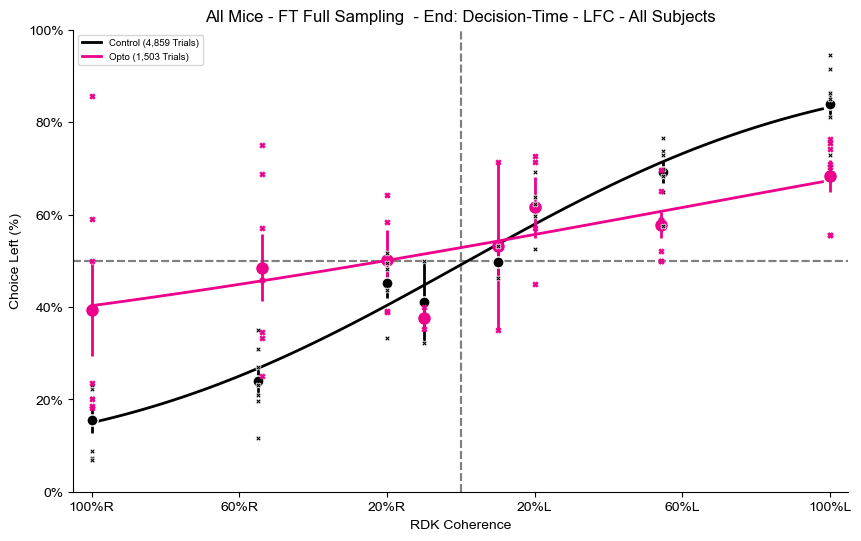

Control Trials: 2131
Opto Trials: 719
Plotting overall psychometric
Plotting overall psychometric
Mean: 100.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


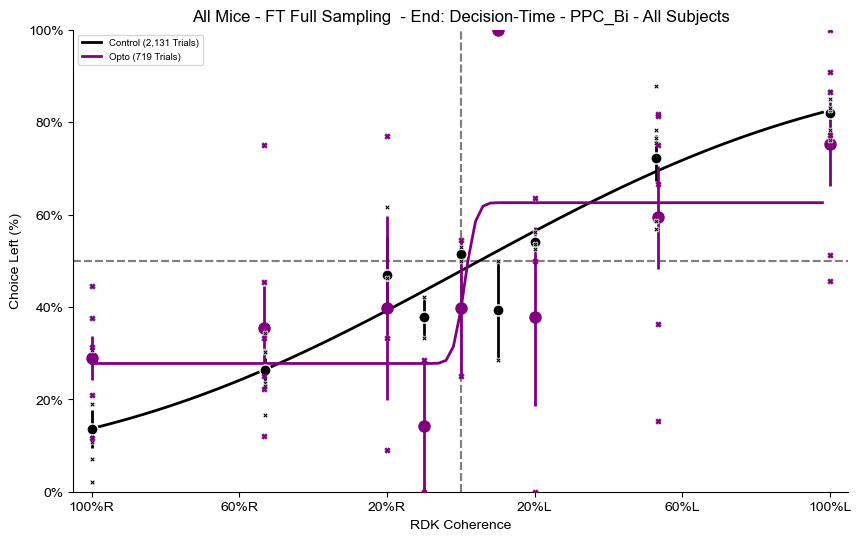

Control Trials: 3704
Opto Trials: 1018
Plotting overall psychometric
Mean: 38.775510204081634 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 71.42857142857143 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


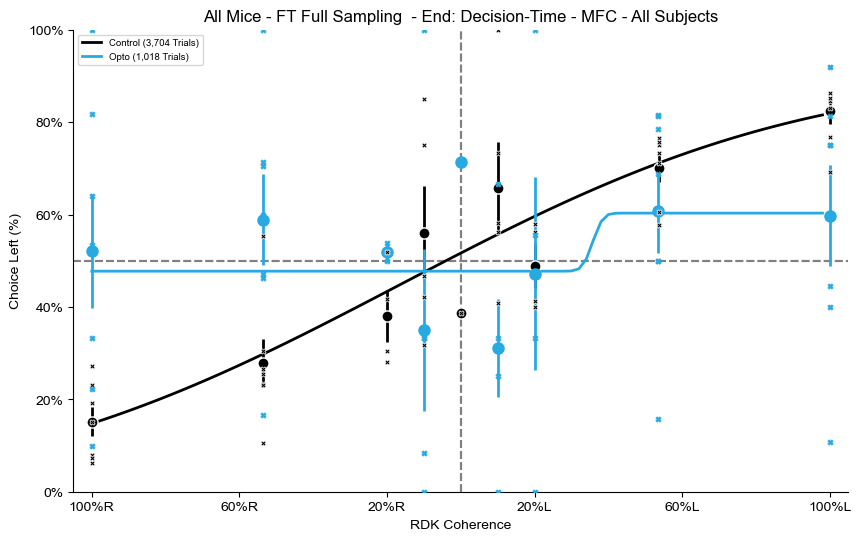

Control Trials: 1719
Opto Trials: 735
Plotting overall psychometric
Mean: 83.33333333333334 - SEM: nan - len(perf_col): 1
Mean: 72.72727272727273 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 16.666666666666664 - SEM: nan - len(perf_col): 1
Mean: 50.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


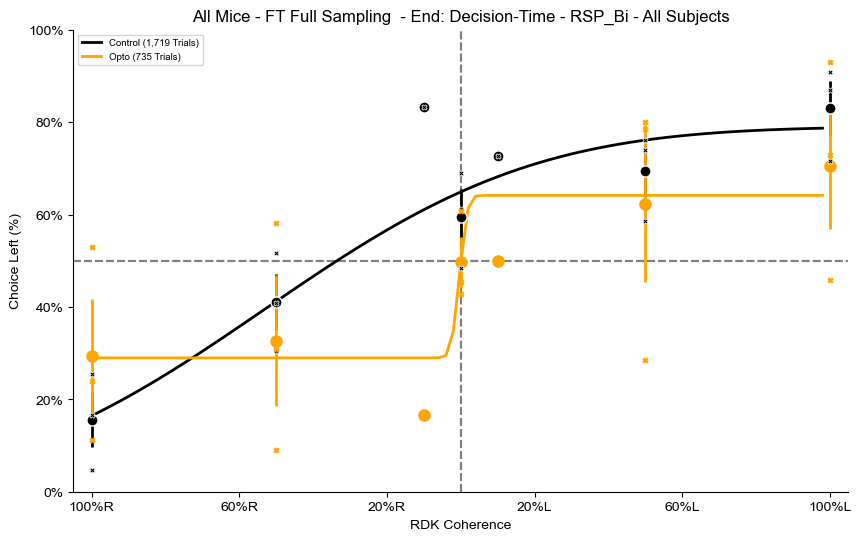

Series([], dtype: int64)

df_full_sampling: 0


Series([], dtype: int64)

[None]

In [ ]:
loopPlotOptoEffect(used_full_ft_df,
                   min_choice_trials=30,
                   save_prefix=save_prefix + "Psychometric/full_ft/",
                   **common_kwargs)

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1254.0,NaN,NaN,NaN,NaN
min,1.5,1.0,0.000900,0.990300,2022-10-02
max,1.5,1.0,1.971200,1.971200,2022-10-16
mean,1.5,1.0,1.393895,1.459793,NaN


Name  GUI_OptoBrainRegion
WF10  15.0                   660
WF13  15.0                   449
WF14  15.0                   145
dtype: int64

df_full_sampling: 1254
End State: 11.0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 1.5              11.0               1.5               14.0                 1254
dtype: int64

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,1254.0,NaN,NaN,NaN,NaN
min,1.5,1.0,0.000900,0.990300,2022-10-02
max,1.5,1.0,1.971200,1.971200,2022-10-16
mean,1.5,1.0,1.393895,1.459793,NaN


Start state: Sampling (1.5s)
Control Trials: 1024
Opto Trials: 230
Plotting overall psychometric
Mean: 25.806451612903224 - SEM: nan - len(perf_col): 1
Mean: 62.857142857142854 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1
Mean: 89.28571428571429 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

Plotting overall psychometric
Mean: 50.0 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1
Mean: 0.0 - SEM: nan - len(perf_col): 1
Mean: 75.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in s

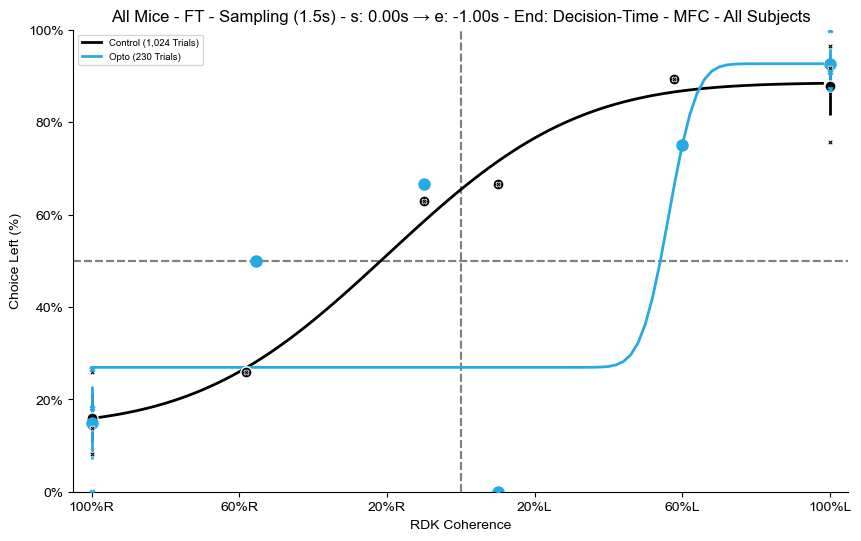

Series([], dtype: int64)

df_full_sampling: 0


Series([], dtype: int64)

[None]

In [ ]:
loopPlotOptoEffect(used_control_df,
                   min_choice_trials=0,
                   only_control_animals=True,
                   save_prefix=save_prefix + "Psychometric/control/",
                   **common_kwargs)

Early trials: 10484, Late trials: 10965
df_full_sampling: 0
df feedback: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.0                 0.35             11.0               1.0               14.0                 10394
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,10394.0,NaN,NaN,NaN,NaN
min,1.0,0.800000,0.000100,0.002000,2020-11-09
max,1.0,1.000000,1.029700,1.000200,2021-12-23
mean,1.0,0.997321,0.969535,0.972181,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,2354.0,NaN,NaN,NaN,NaN
min,1.0,0.810000,0.000100,0.002000,2020-11-09
max,1.0,1.000000,1.029700,1.000200,2021-12-23
mean,1.0,0.997782,0.932131,0.945628,NaN


Start state: Sampling
Control Trials: 3861
Opto Trials: 1279
Plotting overall psychometric
Mean: 100.0 - SEM: nan - len(perf_col): 1
Mean: 66.66666666666666 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 100.0 - SEM: nan - len(perf_col): 1
Mean: 33.33333333333333 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


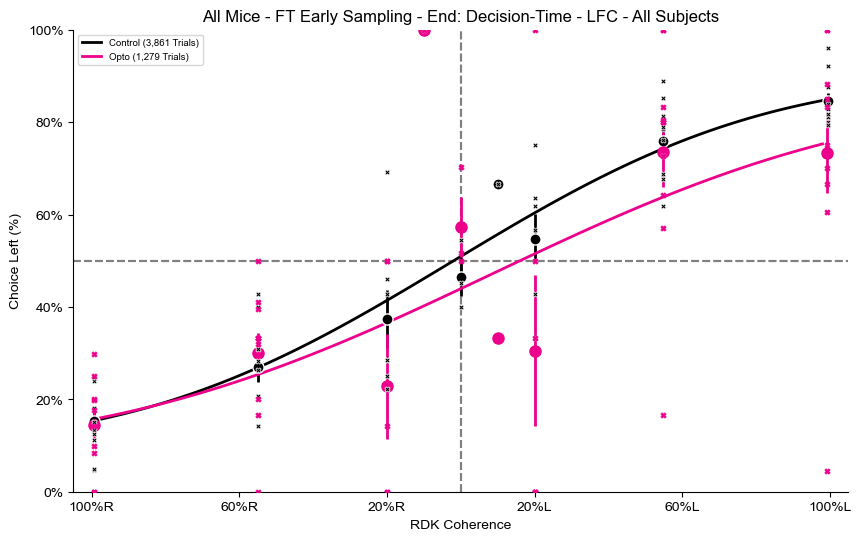

Control Trials: 4179
Opto Trials: 1075
Plotting overall psychometric
Plotting overall psychometric


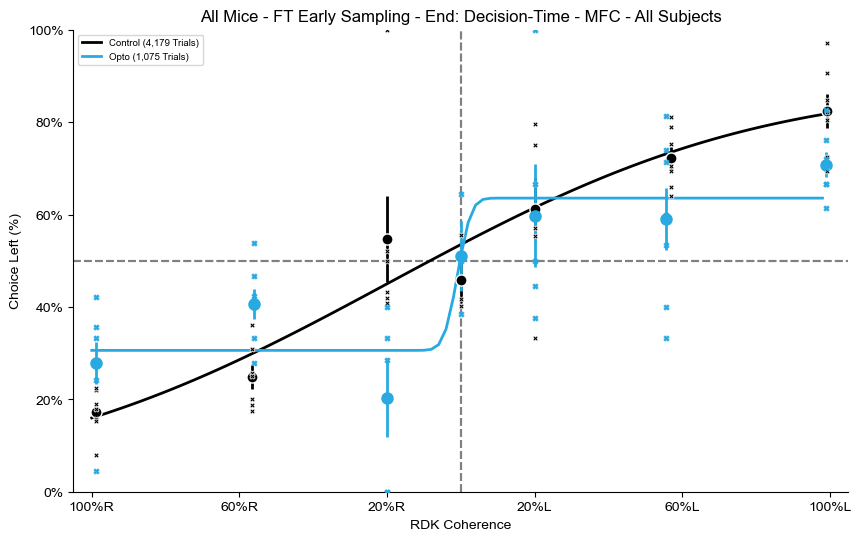

df_full_sampling: 0
df feedback: 0


Series([], dtype: int64)

df_full_sampling: 0
df feedback: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.65                0.35             11.0               1.0               14.0                 10780
dtype: int64

Max ST Values:


...

,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,2189.0,NaN,NaN,NaN,NaN
min,1.0,0.840000,0.0068,0.006800,2020-11-12
max,1.0,1.000000,1.0297,1.000200,2021-12-23
mean,1.0,0.997346,0.9921,0.980014,NaN


Start state: Sampling
Control Trials: 4461
Opto Trials: 997
Plotting overall psychometric
Mean: 61.53846153846154 - SEM: nan - len(perf_col): 1
Mean: 62.5 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Plotting overall psychometric
Mean: 25.0 - SEM: nan - len(perf_col): 1
Mean: 75.0 - SEM: nan - len(perf_col): 1


c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\float\miniconda3\Lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


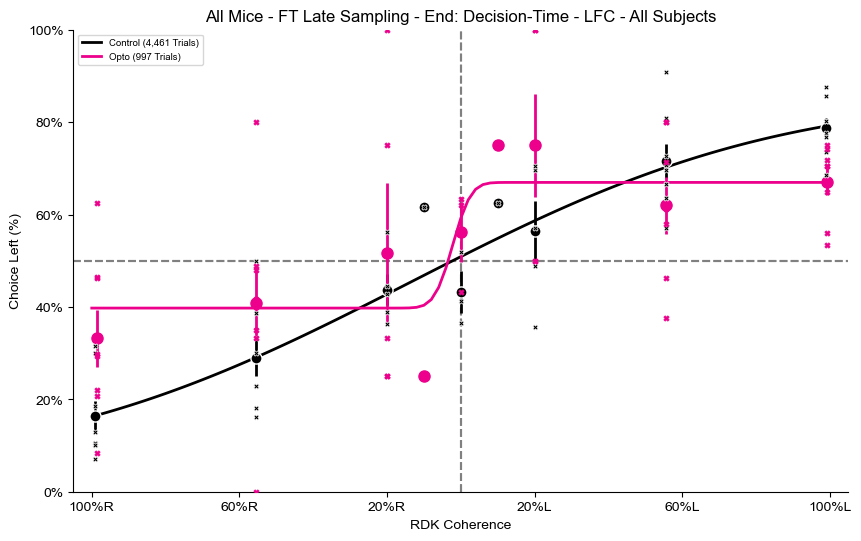

Control Trials: 4130
Opto Trials: 1192
Plotting overall psychometric
Plotting overall psychometric


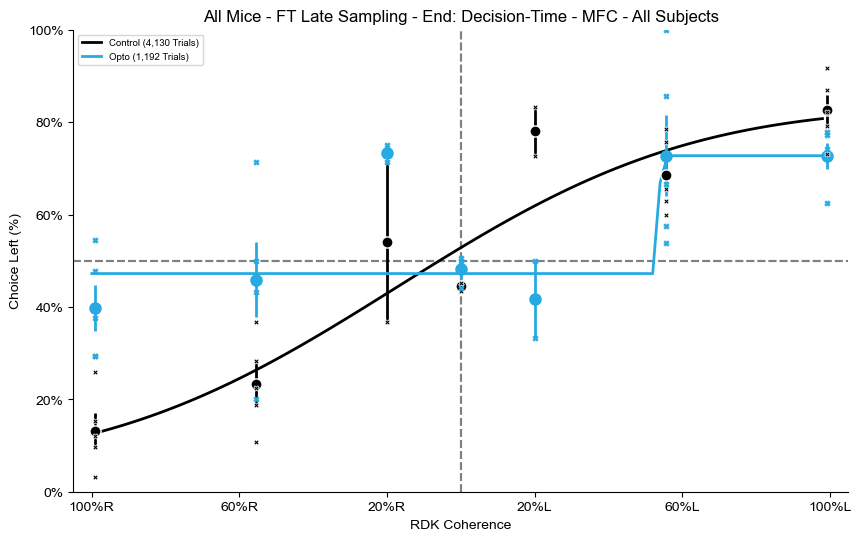

df_full_sampling: 0
df feedback: 0


Series([], dtype: int64)

In [ ]:
def saveEarlyLate():
    used_early_df = used_early_late_ft_df[used_early_late_ft_df.GUI_OptoStartDelay == 0]
    used_late_df = used_early_late_ft_df[used_early_late_ft_df.GUI_OptoStartDelay >= 0.5]
    print(f"Early trials: {len(used_early_df)}, Late trials: {len(used_late_df)}")
    loopPlotOptoEffect(used_early_df,
                       min_choice_trials=30,
                       save_prefix=save_prefix + "Psychometric/early_ft",
                      **common_kwargs)
    loopPlotOptoEffect(used_late_df,
                       min_choice_trials=30,
                       save_prefix=save_prefix + "Psychometric/late_ft",
                      **common_kwargs)

saveEarlyLate()

df_full_sampling: 0


Series([], dtype: int64)

df_full_sampling: 0


GUI_OptoStartState1  GUI_OptoStartDelay  GUI_OptoMaxTime  GUI_OptoEndState1  GUI_StimulusTime  GUI_OptoEndState2
8.0                  0.3                 0.6              11.0               5.0               14.0                 18363
dtype: int64

Max ST Values:


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,18363.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.000200,0.300400,2022-02-21
max,5.0,0.500000,4.895700,4.895700,2023-03-13
mean,5.0,0.311011,1.213376,1.244743,NaN


,GUI_StimulusTime,MinSample,calcStimulusTime,ST,Date
count,3806.0,NaN,NaN,NaN,NaN
min,5.0,0.300000,0.001500,0.303800,2022-02-21
max,5.0,0.500000,4.895700,4.895700,2023-03-13
mean,5.0,0.309879,1.403113,1.435765,NaN


Control Trials: 7291
Opto Trials: 1943
Plotting overall psychometric
Plotting overall psychometric


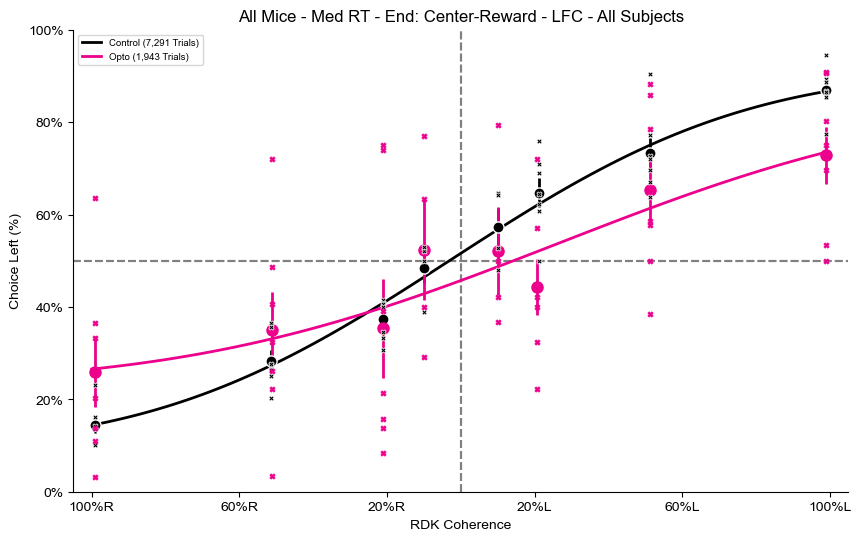

Control Trials: 7266
Opto Trials: 1863
Plotting overall psychometric
Plotting overall psychometric


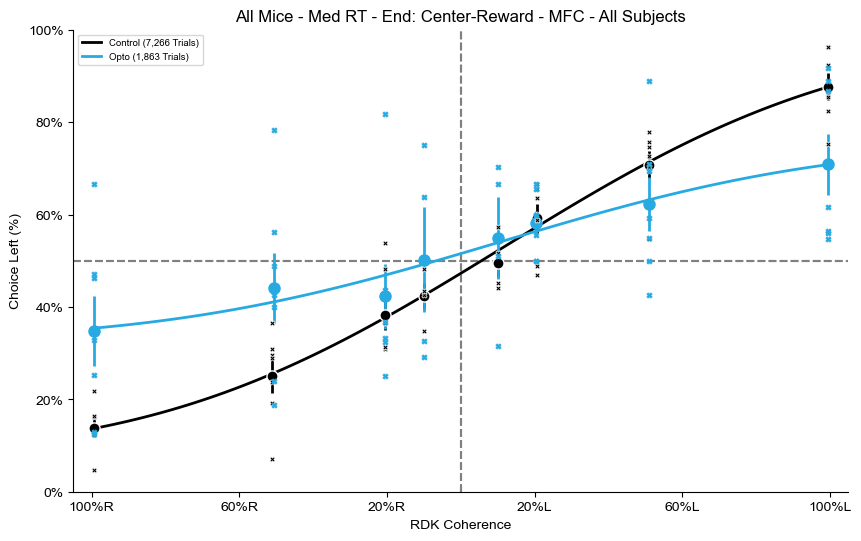

[None]

In [ ]:
loopPlotOptoEffect(used_rt_df,
                   min_choice_trials=30,
                   save_prefix=save_prefix + "Psychometric/free_sampling/",
                   **common_kwargs)